In [5]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Total Return Data Points calculated: 64280
Skewness: 0.1123 | Kurtosis: 3.1018


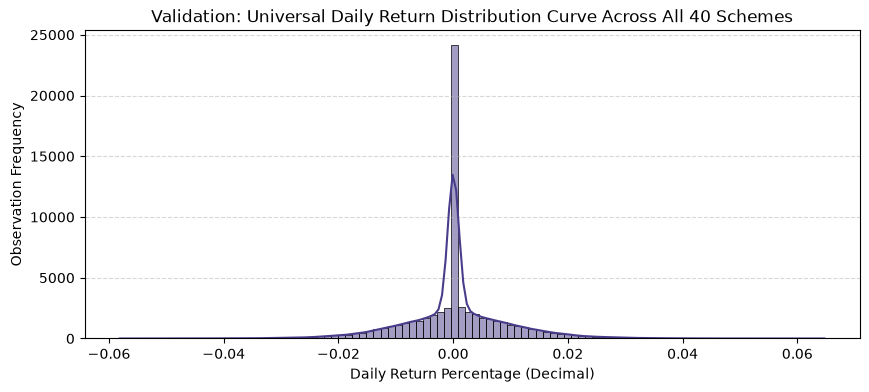

In [19]:
# CELL 1: Environment Setup & Data Ingestion
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


NAV_PATH = "D:/capstone/data/processed/nav_history_cleaned.csv"
MASTER_PATH = "D:/capstone/data/processed/fund_master_cleaned.csv"
BENCHMARK_PATH = "D:/capstone/data/processed/benchmark_indices_cleaned.csv"

df_nav = pd.read_csv(NAV_PATH, parse_dates=['date'])
df_master = pd.read_csv(MASTER_PATH)
df_bench = pd.read_csv(BENCHMARK_PATH, parse_dates=['date'])

df_nav = df_nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)


df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()


print(f"Total Return Data Points calculated: {df_nav['daily_return'].dropna().count()}")
print(f"Skewness: {df_nav['daily_return'].skew():.4f} | Kurtosis: {df_nav['daily_return'].kurt():.4f}")

plt.figure(figsize=(10, 4))
sns.histplot(df_nav['daily_return'].dropna(), kde=True, bins=100, color='darkslateblue')
plt.title('Validation: Universal Daily Return Distribution Curve Across All 40 Schemes')
plt.xlabel('Daily Return Percentage (Decimal)')
plt.ylabel('Observation Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [17]:
# CELL 2: Multi-Year CAGR Compounding
def calculate_timeline_cagr(group, target_years):
    group = group.sort_values('date')
    end_nav = group['nav'].iloc[-1]
    end_date = group['date'].iloc[-1]
    

    days_delta = int(target_years * 365.25)
    historical_target_date = end_date - pd.Timedelta(days=days_delta)
    
    
    past_records = group[group['date'] <= historical_target_date]
    if past_records.empty:
        return np.nan 
        
    start_nav = past_records['nav'].iloc[-1]
    return (end_nav / start_nav) ** (1.0 / target_years) - 1.0

cagr_results = []
for amfi, group in df_nav.groupby('amfi_code'):
    cagr_results.append({
        'amfi_code': amfi,
        'cagr_1yr': calculate_timeline_cagr(group, 1),
        'cagr_3yr': calculate_timeline_cagr(group, 3),
        'cagr_5yr': calculate_timeline_cagr(group, 5) 
    })

df_cagr = pd.DataFrame(cagr_results)
print("Showing sample comparisons:")


display(df_cagr.head())

Showing sample comparisons:


,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.010307,NaN
1,100025,0.037050,0.039025,NaN
2,100033,0.532324,0.324469,NaN
3,101206,0.479241,0.286691,NaN
4,101207,-0.239860,-0.046937,NaN


In [11]:
# CELL 3: Volatility & Downside Risk Metrics
rf_annual = 0.065
rf_daily = (1.0 + rf_annual) ** (1.0 / 252.0) - 1.0

risk_ratios = []
for amfi, group in df_nav.dropna(subset=['daily_return']).groupby('amfi_code'):
    returns = group['daily_return']
    excess_returns = returns - rf_daily
    
 
    volatility = returns.std()
    sharpe = (excess_returns.mean() / volatility) * np.sqrt(252) if volatility > 0 else np.nan
    
    
    downside_returns = returns[returns < 0]
    downside_deviation = np.sqrt(np.mean(downside_returns ** 2))
    sortino = (excess_returns.mean() / downside_deviation) * np.sqrt(252) if downside_deviation > 0 else np.nan
    
    risk_ratios.append({
        'amfi_code': amfi,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino
    })

df_risk_metrics = pd.DataFrame(risk_ratios)


In [ ]:
# CELL 4: Regression Analysis & Drawdown Trajectories



df_bench_pivot = df_bench.pivot(index='date', columns='index_name', values='close_value').sort_index()
df_bench_returns = df_bench_pivot.pct_change().dropna()

regression_metrics = []
drawdown_metrics = []

print("⏳ Calculating Alpha, Beta, and Maximum Drawdowns...")

for amfi, group in df_nav.dropna(subset=['daily_return']).groupby('amfi_code'):
   
    
    fund_series = group.set_index('date')['daily_return']
    aligned_market = pd.concat([fund_series, df_bench_returns['NIFTY100']], axis=1, join='inner').dropna()
    aligned_market.columns = ['fund', 'nifty100']
    
   
    if len(aligned_market) >= 30:
        beta, intercept, _, _, _ = stats.linregress(aligned_market['nifty100'], aligned_market['fund'])
        alpha = intercept * 252.0 
    else:
        beta, alpha = np.nan, np.nan
        
    regression_metrics.append({'amfi_code': amfi, 'alpha': alpha, 'beta': beta})
    
  
    sorted_group = group.sort_values('date').copy().reset_index(drop=True)
    sorted_group['running_peak'] = sorted_group['nav'].cummax()
    sorted_group['drawdown_curve'] = (sorted_group['nav'] / sorted_group['running_peak']) - 1.0
    
    max_dd = sorted_group['drawdown_curve'].min()
    
   
    if not pd.isna(max_dd):
        trough_idx = sorted_group['drawdown_curve'].idxmin()
        trough_date = sorted_group.loc[trough_idx, 'date']
        
   
        peak_records = sorted_group.loc[:trough_idx]
        peak_date = peak_records[peak_records['nav'] == sorted_group.loc[trough_idx, 'running_peak']]['date'].iloc[-1]
        
        drawdown_metrics.append({
            'amfi_code': amfi,
            'max_drawdown': max_dd,
            'drawdown_start': peak_date.strftime('%Y-%m-%d'),
            'drawdown_end': trough_date.strftime('%Y-%m-%d')
        })


df_reg_final = pd.DataFrame(regression_metrics)
df_dd_final = pd.DataFrame(drawdown_metrics)


df_reg_final.to_csv("D:/capstone/data/processed/alpha_beta.csv", index=False)
print("'alpha_beta.csv' generated and saved successfully to your processed folder.")
print("Maximum Drawdown metrics calculated successfully for all 40 funds.")

display(pd.merge(df_reg_final, df_dd_final, on='amfi_code').head())


⏳ Calculating Alpha, Beta, and Maximum Drawdowns...
✅ Standalone 'alpha_beta.csv' generated and saved successfully to your processed folder.
📉 Maximum Drawdown metrics calculated successfully for all 40 funds.


,amfi_code,alpha,beta,max_drawdown,drawdown_start,drawdown_end
0,100016,0.026793,-0.058190,-0.247344,2022-03-30,2022-09-15
1,100025,0.030613,0.001248,-0.043083,2023-05-23,2023-07-28
2,100033,0.194433,0.005674,-0.162172,2022-03-13,2022-05-12
3,101206,0.152998,0.021535,-0.112916,2023-04-24,2023-07-05
4,101207,0.077909,-0.065061,-0.354469,2024-11-21,2026-05-11


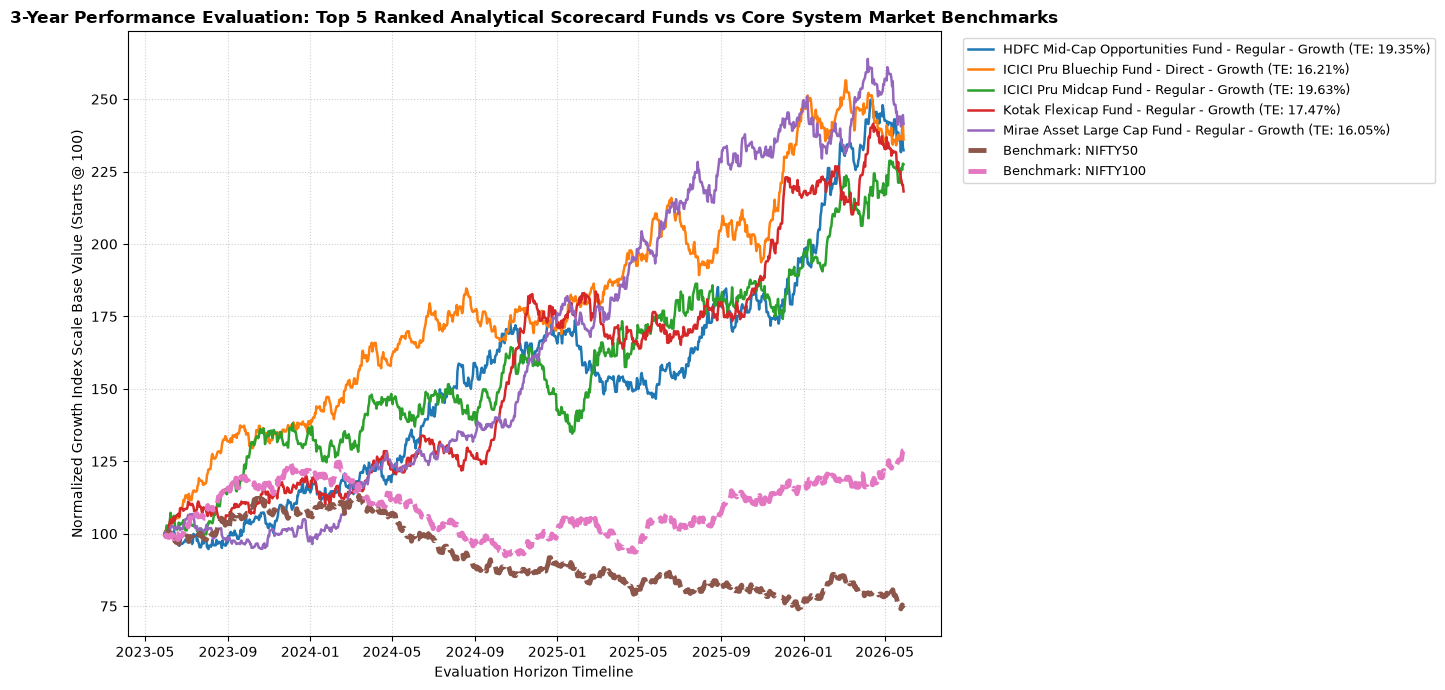

In [18]:
# CELL 5: Composite Scorecard Calculations & Comparative Charting


df_scorecard = df_master[['amfi_code', 'scheme_name', 'fund_house', 'expense_ratio_pct']].copy()
df_scorecard = df_scorecard.merge(df_cagr, on='amfi_code') \
                           .merge(df_risk_metrics, on='amfi_code') \
                           .merge(df_reg_final, on='amfi_code') \
                           .merge(df_dd_final, on='amfi_code')


df_scorecard['rank_returns'] = df_scorecard['cagr_3yr'].rank(pct=True)
df_scorecard['rank_sharpe'] = df_scorecard['sharpe_ratio'].rank(pct=True)
df_scorecard['rank_alpha'] = df_scorecard['alpha'].rank(pct=True)
df_scorecard['rank_expense'] = df_scorecard['expense_ratio_pct'].rank(pct=True, ascending=False)
df_scorecard['rank_drawdown'] = df_scorecard['max_drawdown'].rank(pct=True) 


df_scorecard['fund_score'] = (
    0.30 * df_scorecard['rank_returns'] +
    0.25 * df_scorecard['rank_sharpe'] +
    0.20 * df_scorecard['rank_alpha'] +
    0.15 * df_scorecard['rank_expense'] +
    0.10 * df_scorecard['rank_drawdown']
) * 100.0


df_scorecard = df_scorecard.sort_values('fund_score', ascending=False).reset_index(drop=True)
df_scorecard.to_csv("D:/capstone/data/processed/fund_scorecard.csv", index=False)


top_5_codes = df_scorecard['amfi_code'].head(5).tolist()

df_plot_funds = df_nav[df_nav['amfi_code'].isin(top_5_codes)].pivot(index='date', columns='amfi_code', values='nav')
df_chart_master = pd.concat([df_plot_funds, df_bench_pivot[['NIFTY50', 'NIFTY100']]], axis=1, join='inner').dropna().sort_index()


three_years_ago = df_chart_master.index[-1] - pd.Timedelta(days=3*365.25)
df_chart_3yr = df_chart_master[df_chart_master.index >= three_years_ago]
df_chart_normalized = (df_chart_3yr / df_chart_3yr.iloc[0]) * 100.0

plt.figure(figsize=(14, 7))

for column in df_chart_normalized.columns:
    if column in ['NIFTY50', 'NIFTY100']:
        plt.plot(df_chart_normalized.index, df_chart_normalized[column], label=f"Benchmark: {column}", linewidth=3.5, linestyle='--')
    else:
        scheme_title = df_scorecard[df_scorecard['amfi_code'] == column]['scheme_name'].values[0]
       
        fund_ret = df_chart_master[column].pct_change()
        bench_ret = df_chart_master['NIFTY100'].pct_change()
        tracking_error = (fund_ret - bench_ret).std() * np.sqrt(252) * 100
        plt.plot(df_chart_normalized.index, df_chart_normalized[column], label=f"{scheme_title} (TE: {tracking_error:.2f}%)", linewidth=1.8)

plt.title('3-Year Performance Evaluation: Top 5 Ranked Analytical Scorecard Funds vs Core System Market Benchmarks', fontsize=12, fontweight='bold')
plt.xlabel('Evaluation Horizon Timeline')
plt.ylabel('Normalized Growth Index Scale Base Value (Starts @ 100)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('D:/capstone/notebooks/exports/charts/benchmark_comparison_chart.png', dpi=300)
plt.show()